## Business Objective

The objective of this project is to analyze the transfer strategies of football clubs from the top seven European leagues and the Russian Premier League starting from 2022.

The year 2022 was chosen as the starting point because it represents the post-COVID period, when football clubs returned to more stable financial and sporting conditions after the disruptions caused by the pandemic.

The analysis focuses on identifying patterns, similarities, and differences in how clubs behave in the transfer market when acquiring players.

## Machine Learning Task

The main machine learning task is to perform **clustering analysis** in order to identify groups of football clubs with similar transfer strategies.

## Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

##  Exploratory Data Analysis

In [2]:
file_path1 = "transfers.csv"

df1 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "davidcariboo/player-scores",
  file_path1,
)

/tmp/ipykernel_445/3083535835.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df1 = kagglehub.load_dataset(


100%|██████████| 8.05M/8.05M [00:00<00:00, 25.4MB/s]


In [3]:
df1.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,1077560,2027-06-30,26/27,3060,683,Atromitos,Olympiacos,0.0,1000000.0,Stavros Pnevmonidis
2,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.0,NaN,Yannick Nkurunziza
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan
4,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.0,6000000.0,Monchu


In [4]:
file_path2 = "clubs.csv"

df2 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "davidcariboo/player-scores",
  file_path2,
)

/tmp/ipykernel_445/522046252.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df2 = kagglehub.load_dataset(


100%|██████████| 99.2k/99.2k [00:00<00:00, 1.39MB/s]


In [5]:
df2.head()

,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,10,arminia-bielefeld,Arminia Bielefeld,L1,NaN,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
1,10004,paris-fc,Paris Football Club,FR1,NaN,31,28.5,17,54.8,9,Stade Jean Bouin,19904,€-72.30m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/paris-fc/start...
2,1003,leicester-city,Leicester City,GB1,NaN,29,25.8,17,58.6,10,King Power Stadium,32259,+€57.30m,NaN,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/leicester-city...
3,1005,us-lecce,Unione Sportiva Lecce,IT1,NaN,27,25.1,23,85.2,10,Ettore Giardiniero,31559,+€8.62m,NaN,2025,../data/raw/transfermarkt-scraper/2025/clubs.j...,https://www.transfermarkt.co.uk/us-lecce/start...
4,1010,fc-watford,Watford FC,GB1,NaN,30,26.3,24,80.0,12,Vicarage Road,21577,+€42.02m,NaN,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/fc-watford/sta...


In [6]:
df1 = df1.merge(
    df2[['club_id', 'domestic_competition_id']],
    left_on='to_club_id',
    right_on='club_id',
    how='left'
)

df1.drop(columns='club_id', inplace=True)

In [7]:
df1.head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli,IT1
1,1077560,2027-06-30,26/27,3060,683,Atromitos,Olympiacos,0.0,1000000.0,Stavros Pnevmonidis,GR1
2,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.0,NaN,Yannick Nkurunziza,TR1
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan,GB1
4,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.0,6000000.0,Monchu,GR1


In [8]:
df1.shape

(99653, 11)

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99653 entries, 0 to 99652
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                99653 non-null  int64  
 1   transfer_date            99653 non-null  object 
 2   transfer_season          99653 non-null  object 
 3   from_club_id             99653 non-null  int64  
 4   to_club_id               99653 non-null  int64  
 5   from_club_name           99653 non-null  object 
 6   to_club_name             99653 non-null  object 
 7   transfer_fee             65499 non-null  float64
 8   market_value_in_eur      61477 non-null  float64
 9   player_name              99653 non-null  object 
 10  domestic_competition_id  44261 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 8.4+ MB


In [10]:
# Number of Missing Values
df1.isnull().sum()

,0
player_id,0
transfer_date,0
transfer_season,0
from_club_id,0
to_club_id,0
from_club_name,0
to_club_name,0
transfer_fee,34154
market_value_in_eur,38176
player_name,0


In [11]:
# Removing rows with missing values in the columns
df = df1.dropna(subset=['transfer_fee', 'market_value_in_eur', 'domestic_competition_id'])

In [12]:
df.isnull().sum()

,0
player_id,0
transfer_date,0
transfer_season,0
from_club_id,0
to_club_id,0
from_club_name,0
to_club_name,0
transfer_fee,0
market_value_in_eur,0
player_name,0


In [13]:
# Date Filtering
df['transfer_date'] = pd.to_datetime(df['transfer_date'], errors='coerce')
df = df[df['transfer_date'].dt.year >= 2022]

/tmp/ipykernel_445/3434836807.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transfer_date'] = pd.to_datetime(df['transfer_date'], errors='coerce')


In [14]:
# Selecting the leagues of interest
target_leagues = ['GB1', 'ES1', 'FR1', 'IT1', 'NL1', 'PO1', 'L1', 'RU1']

df = df[df['domestic_competition_id'].isin(target_leagues)]

In [15]:
df

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli,IT1
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan,GB1
5,371996,2026-12-31,26/27,6600,2410,Internacional,CSKA Moscow,0.0,3000000.0,Alerrandro,RU1
6,401533,2026-12-31,26/27,2029,2423,Ceará SC,Santa Clara,0.0,1500000.0,Matheusinho,PO1
9,541914,2026-12-31,26/27,713,1124,BATE Borisov,Fakel Voronezh,0.0,225000.0,Anton Kovalev,RU1
...,...,...,...,...,...,...,...,...,...,...,...
39582,599150,2022-01-01,21/22,1124,232,Fakel Voronezh,Spartak Moscow,250000.0,350000.0,Ilya Svinov,RU1
39590,621436,2022-01-01,21/22,3729,232,Arsenal Tula,Spartak Moscow,3000000.0,3500000.0,Daniil Khlusevich,RU1
39653,712857,2022-01-01,21/22,14300,932,Shakhtar U19,Loko Moscow,3000000.0,1000000.0,Mark Mampassi,RU1
39689,789082,2022-01-01,21/22,210,162,Grêmio,Monaco,11000000.0,8500000.0,Vanderson,FR1


In [16]:
df.shape

(12287, 11)

In [17]:
df_clean = df.copy()

# Add flags for free and paid transfers
df_clean['is_paid'] = df_clean['transfer_fee'] > 0
df_clean['is_free'] = df_clean['transfer_fee'] == 0

In [18]:
# Creating a table with the required features
club_stats = df_clean.groupby('to_club_name').agg(
    total_fee=('transfer_fee', 'sum'),  # 2. Total amount of money spent
    num_transfers=('player_id', 'count'),  # 3. Total number of players signed
    paid_transfers=('is_paid', 'sum'),  # 4. Players purchased for a fee
    free_transfers=('is_free', 'sum'),  # 5. Players signed for free
    total_market_value=('market_value_in_eur', 'sum'),  # 7. Total market value
).reset_index()

# 6. Average transfer fee per paid player
club_stats['avg_fee_per_paid_player'] = club_stats.apply(
    lambda row: row['total_fee'] / row['paid_transfers'] if row['paid_transfers'] > 0 else 0,
    axis=1
)

# 8. Average market value of signed players
club_stats['avg_market_value_per_player'] = club_stats.apply(
    lambda row: row['total_market_value'] / row['num_transfers'] if row['num_transfers'] > 0 else 0,
    axis=1
)

# 9. Total difference between market value and transfer spending
club_stats['value_diff'] = club_stats['total_market_value'] - club_stats['total_fee']

# 10. Average difference per player
club_stats['value_diff_per_player'] = club_stats.apply(
    lambda row: row['value_diff'] / row['num_transfers'] if row['num_transfers'] > 0 else 0,
    axis=1
)

In [20]:
# Rename the club name column for convenience
club_stats = club_stats.rename(columns={'to_club_name': 'club'})

In [21]:
# Final Table
club_stats = club_stats[[
    'club',
    'total_fee',
    'num_transfers',
    'paid_transfers',
    'free_transfers',
    'avg_fee_per_paid_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]]

In [22]:
club_stats = club_stats.round()

In [23]:
club_stats

,club,total_fee,num_transfers,paid_transfers,free_transfers,avg_fee_per_paid_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
0,1.FC Köln,37300000.0,50,17,33,2194118.0,1.199000e+08,2398000.0,82600000.0,1652000.0
1,1.FC Nuremberg,21450000.0,29,6,23,3575000.0,5.705000e+07,1967241.0,35600000.0,1227586.0
2,1.FSV Mainz 05,2300000.0,8,1,7,2300000.0,2.095000e+07,2618750.0,18650000.0,2331250.0
3,AC Ajaccio,0.0,6,0,6,0.0,4.950000e+06,825000.0,4950000.0,825000.0
4,AC Milan,477410000.0,95,30,65,15913667.0,1.009200e+09,10623158.0,531790000.0,5597789.0
...,...,...,...,...,...,...,...,...,...,...
289,Wigan,35000.0,21,1,20,35000.0,1.490000e+07,709524.0,14865000.0,707857.0
290,Willem II,2375000.0,25,5,20,475000.0,1.220000e+07,488000.0,9825000.0,393000.0
291,Wolfsburg,230480000.0,68,27,41,8536296.0,4.608000e+08,6776471.0,230320000.0,3387059.0
292,Wolves,505607000.0,97,32,65,15800219.0,8.223250e+08,8477577.0,316718000.0,3265134.0


/tmp/ipykernel_445/3210814665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


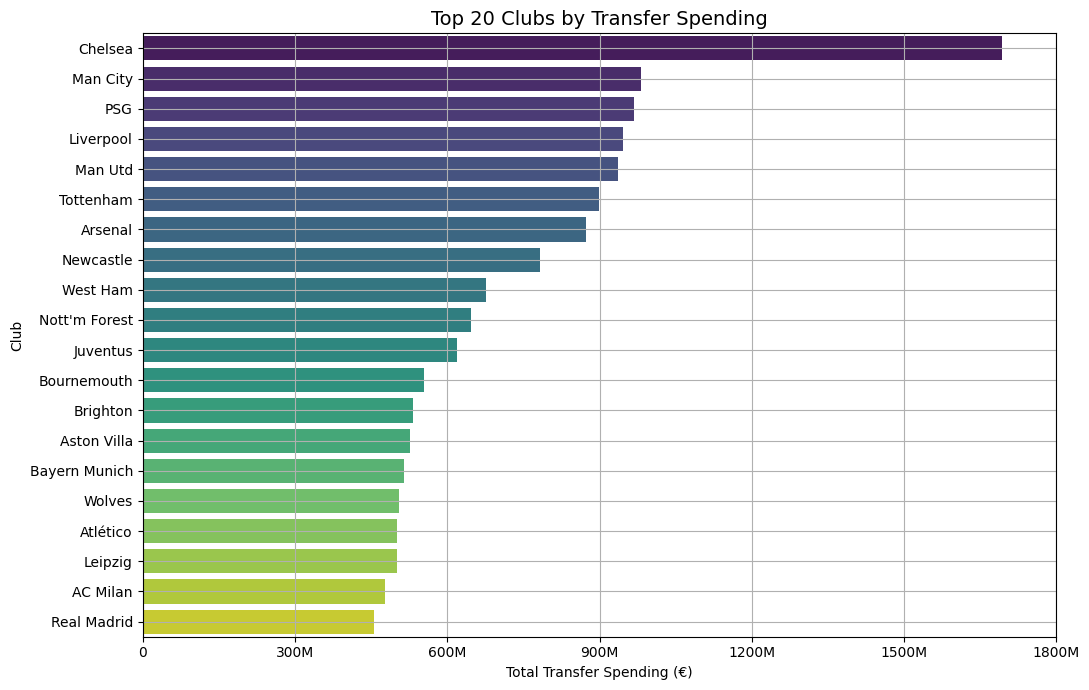

In [27]:
# Top 20 clubs by transfer spending
top_clubs = club_stats.sort_values(by='total_fee', ascending=False).head(20)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_clubs,
    y='club',
    x='total_fee',
    palette='viridis'
)

plt.xlim(0, 1400_000_000)
plt.xticks(
    ticks=[0, 300_000_000, 600_000_000, 900_000_000, 1200_000_000, 1500_000_000, 1800_000_000],
    labels=['0', '300M','600M', '900M','1200M', '1500M', '1800M']
)

plt.title('Top 20 Clubs by Transfer Spending', fontsize=14)
plt.xlabel('Total Transfer Spending (€)')
plt.ylabel('Club')

plt.tight_layout()
plt.grid()
plt.show()

/tmp/ipykernel_445/3780404790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


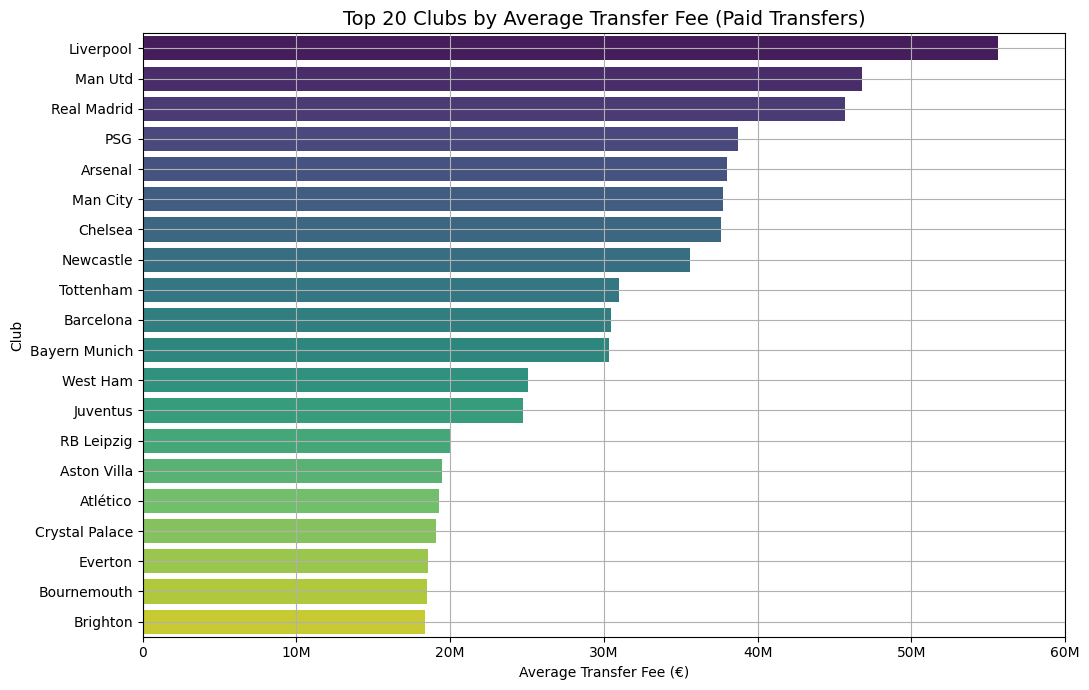

In [28]:
# Top 20 clubs by average transfer fee (paid transfers)
top_clubs = club_stats.sort_values(by='avg_fee_per_paid_player', ascending=False).head(20)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_clubs,
    y='club',
    x='avg_fee_per_paid_player',
    palette='viridis'
)

plt.xlim(0, 60_000_000)
plt.xticks(
    ticks=[0, 10_000_000, 20_000_000, 30_000_000, 40_000_000, 50_000_000, 60_000_000],
    labels=['0', '10M', '20M', '30M', '40M', '50M', '60M']
)

plt.title('Top 20 Clubs by Average Transfer Fee (Paid Transfers)', fontsize=14)
plt.xlabel('Average Transfer Fee (€)')
plt.ylabel('Club')

plt.tight_layout()
plt.grid()
plt.show()

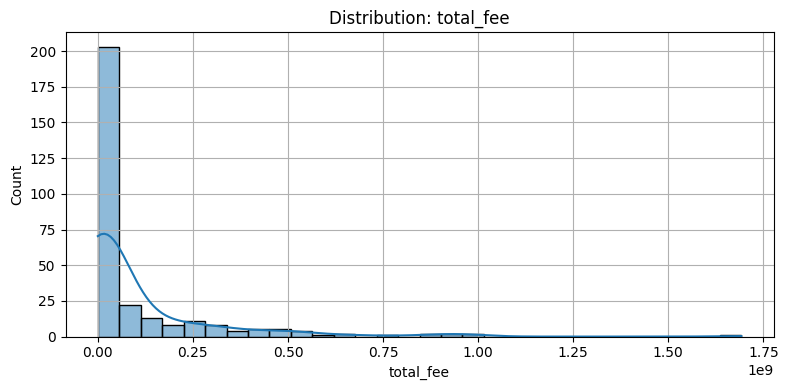

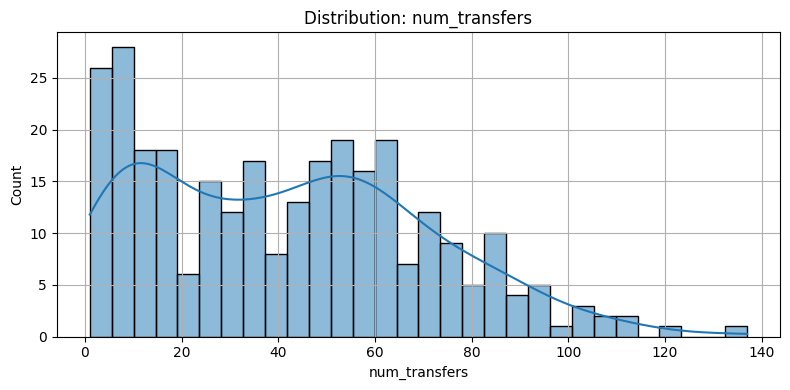

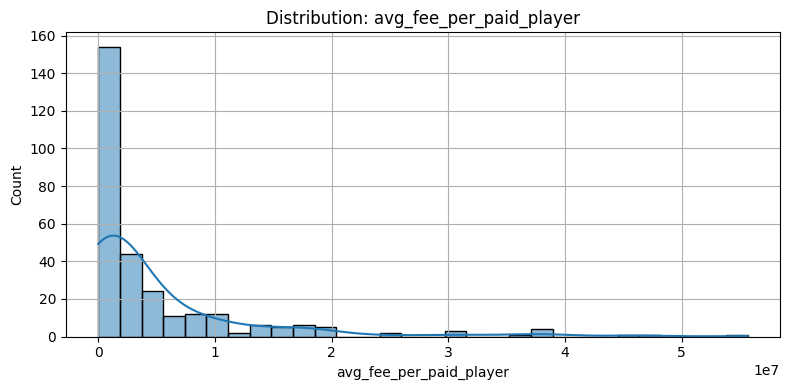

In [29]:
# Distribution of selected features

cols = ['total_fee', 'num_transfers', 'avg_fee_per_paid_player']

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(club_stats[col], kde=True, bins=30)
    plt.title(f'Distribution: {col}')
    plt.grid()
    plt.tight_layout()
    plt.show()

## Feature Engineering

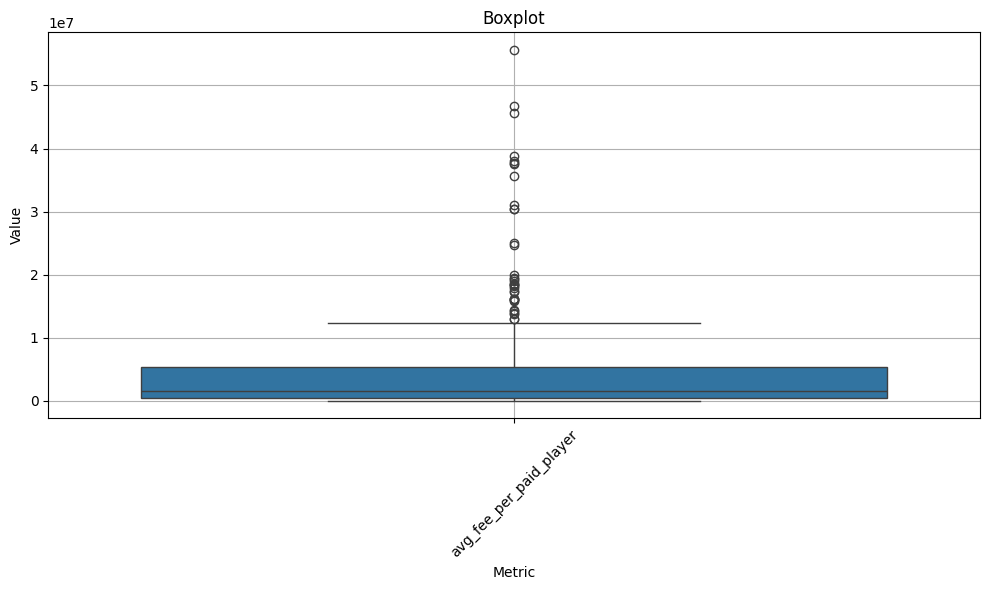

In [30]:
# Select numerical features of interest
numeric_cols = ['avg_fee_per_paid_player']

# Create a long DataFrame for easier visualization
club_stats_melted = club_stats.melt(value_vars=numeric_cols, var_name='Metric', value_name='Value')

# Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=club_stats_melted, x='Metric', y='Value')
plt.title('Boxplot')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [31]:
df[df['to_club_name'] == 'Barcelona'].head()

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id
103,74857,2026-06-30,25/26,12321,131,Girona,Barcelona,0.0,7000000.0,Marc-André ter Stegen,ES1
189,283170,2026-06-30,25/26,1531,131,Elche CF,Barcelona,0.0,8000000.0,Iñaki Peña,ES1
375,466810,2026-06-30,25/26,162,131,Monaco,Barcelona,0.0,10000000.0,Ansu Fati,ES1
964,937955,2026-06-30,25/26,1531,131,Elche CF,Barcelona,0.0,12000000.0,Héctor Fort,ES1
2622,182712,2026-01-13,25/26,1114,131,Al-Hilal,Barcelona,0.0,10000000.0,João Cancelo,ES1


In [32]:
df_new = df_clean.copy()
df_new = df_new[df_new['transfer_fee'] > 0]

In [33]:
df_new[df_new['to_club_name'] == 'Barcelona']

,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name,domestic_competition_id,is_paid,is_free
5760,792331,2025-07-14,25/26,190,131,Copenhagen,Barcelona,2500000.0,7500000.0,Roony Bardghji,ES1,True,False
6906,561613,2025-07-01,25/26,714,131,Espanyol,Barcelona,25000000.0,25000000.0,Joan García,ES1,True,False
12628,293385,2024-08-09,24/25,23826,131,Leipzig,Barcelona,55000000.0,60000000.0,Dani Olmo,ES1,True,False
13144,707572,2024-07-24,24/25,12321,131,Girona,Barcelona,5500000.0,1500000.0,Pau Víctor,ES1,True,False
20928,943837,2024-01-01,23/24,679,131,Athletico-PR,Barcelona,30000000.0,40000000.0,Vitor Roque,ES1,True,False
23781,66100,2023-07-19,23/24,12321,131,Girona,Barcelona,3400000.0,5000000.0,Oriol Romeu,ES1,True,False
32505,411975,2022-07-28,22/23,368,131,Sevilla FC,Barcelona,50000000.0,60000000.0,Jules Koundé,ES1,True,False
32801,38253,2022-07-19,22/23,27,131,Bayern Munich,Barcelona,45000000.0,45000000.0,Robert Lewandowski,ES1,True,False
33082,411295,2022-07-13,22/23,399,131,Leeds,Barcelona,58000000.0,45000000.0,Raphinha,ES1,True,False
34982,720038,2022-07-01,22/23,630,131,Racing,Barcelona,6000000.0,3000000.0,Pablo Torre,ES1,True,False


In [34]:
# Create a new table with selected features

club_stats_new = df_new.groupby('to_club_name').agg(
    total_fee=('transfer_fee', 'sum'),  # 2. Total transfer spending
    num_transfers=('player_id', 'count'),  # 3. Total number of players signed
    total_market_value=('market_value_in_eur', 'sum'),  # 5. Total market value
).reset_index()

# 4. Average transfer fee per player
club_stats_new['avg_fee_per_player'] = club_stats_new.apply(
    lambda row: row['total_fee'] / row['num_transfers'],
    axis=1
)

# 6. Average market value of signed players
club_stats_new['avg_market_value_per_player'] = club_stats_new.apply(
    lambda row: row['total_market_value'] / row['num_transfers'],
    axis=1
)

# 7. Total difference between market value and transfer spending
club_stats_new['value_diff'] = club_stats_new['total_market_value'] - club_stats_new['total_fee']

# 8. Average difference per player
club_stats_new['value_diff_per_player'] = club_stats_new.apply(
    lambda row: row['value_diff'] / row['num_transfers'],
    axis=1
)

In [35]:
club_stats_new = club_stats_new.rename(columns={'to_club_name': 'club'})

In [36]:
# Final table with selected features
club_stats_new = club_stats_new[[
    'club',
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]]

In [37]:
club_stats_new = club_stats_new.round()
club_stats_new

,club,total_fee,num_transfers,avg_fee_per_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
0,1.FC Köln,37300000.0,17,2194118.0,51650000.0,3038235.0,14350000.0,844118.0
1,1.FC Nuremberg,21450000.0,6,3575000.0,18700000.0,3116667.0,-2750000.0,-458333.0
2,1.FSV Mainz 05,2300000.0,1,2300000.0,2500000.0,2500000.0,200000.0,200000.0
3,AC Milan,477410000.0,30,15913667.0,493750000.0,16458333.0,16340000.0,544667.0
4,AJ Auxerre,13450000.0,10,1345000.0,13800000.0,1380000.0,350000.0,35000.0
...,...,...,...,...,...,...,...,...
240,Wigan,35000.0,1,35000.0,1800000.0,1800000.0,1765000.0,1765000.0
241,Willem II,2375000.0,5,475000.0,2300000.0,460000.0,-75000.0,-15000.0
242,Wolfsburg,230480000.0,27,8536296.0,242500000.0,8981481.0,12020000.0,445185.0
243,Wolves,505607000.0,32,15800219.0,412000000.0,12875000.0,-93607000.0,-2925219.0


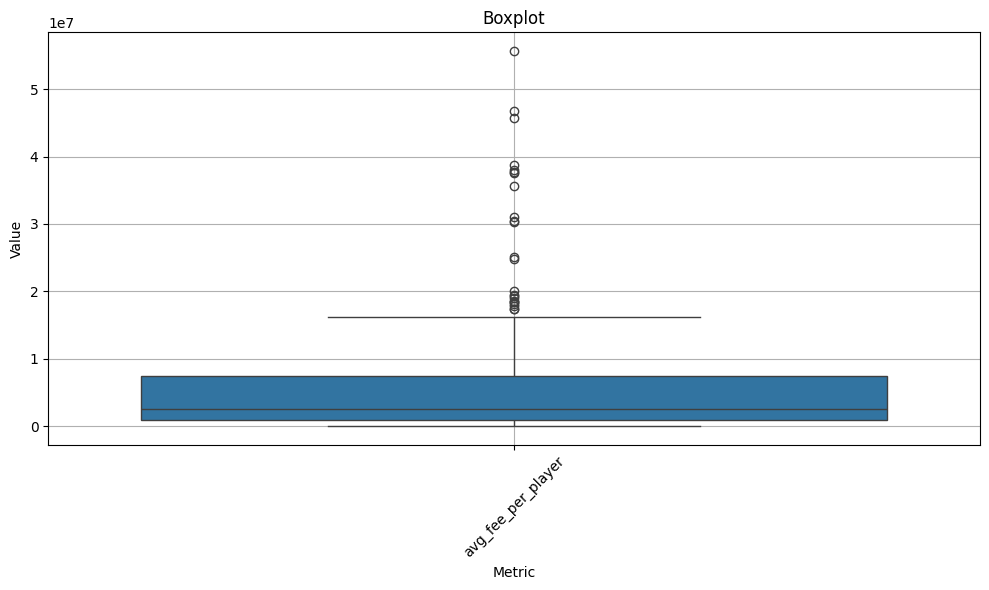

In [38]:
# Select numerical features of interest
numeric_cols = ['avg_fee_per_player']

# Create a long DataFrame for easier visualization
club_stats_new_melted = club_stats_new.melt(value_vars=numeric_cols, var_name='Metric', value_name='Value')

# Plot the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=club_stats_new_melted, x='Metric', y='Value')
plt.title('Boxplot')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## Model Construction

In [39]:
# Full set of features for clustering
features = club_stats_new[[
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]].copy()

In [40]:
features.round().head()

,total_fee,num_transfers,avg_fee_per_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
0,37300000.0,17,2194118.0,51650000.0,3038235.0,14350000.0,844118.0
1,21450000.0,6,3575000.0,18700000.0,3116667.0,-2750000.0,-458333.0
2,2300000.0,1,2300000.0,2500000.0,2500000.0,200000.0,200000.0
3,477410000.0,30,15913667.0,493750000.0,16458333.0,16340000.0,544667.0
4,13450000.0,10,1345000.0,13800000.0,1380000.0,350000.0,35000.0


In [41]:
# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

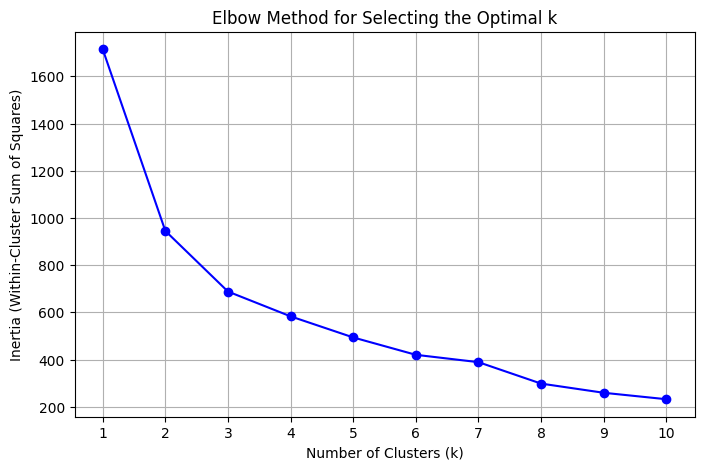

In [42]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)  # inertia = sum of squared distances to cluster centers

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Selecting the Optimal k')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [43]:
# Set the number of clusters (for example, 4)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Train the model on the features
kmeans.fit(features_scaled)

# Get cluster labels
features['cluster'] = kmeans.labels_

In [44]:
# Average feature values within each cluster
cluster_summary = features.groupby('cluster').mean(numeric_only=True)
cluster_summary.round()

,total_fee,num_transfers,avg_fee_per_player,total_market_value,avg_market_value_per_player,value_diff,value_diff_per_player
cluster,,,,,,,
0,274116018.0,27.0,10549865.0,253748246.0,9674954.0,-20367772.0,-874910.0
1,21323264.0,9.0,2198387.0,24630747.0,2753465.0,3307483.0,555078.0
2,919900000.0,29.0,32402897.0,675366667.0,23859934.0,-244533333.0,-8542963.0
3,711983750.0,19.0,37668142.0,700400000.0,37277540.0,-11583750.0,-390602.0


/tmp/ipykernel_445/665835230.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  labeled_samples = features.groupby('cluster').apply(


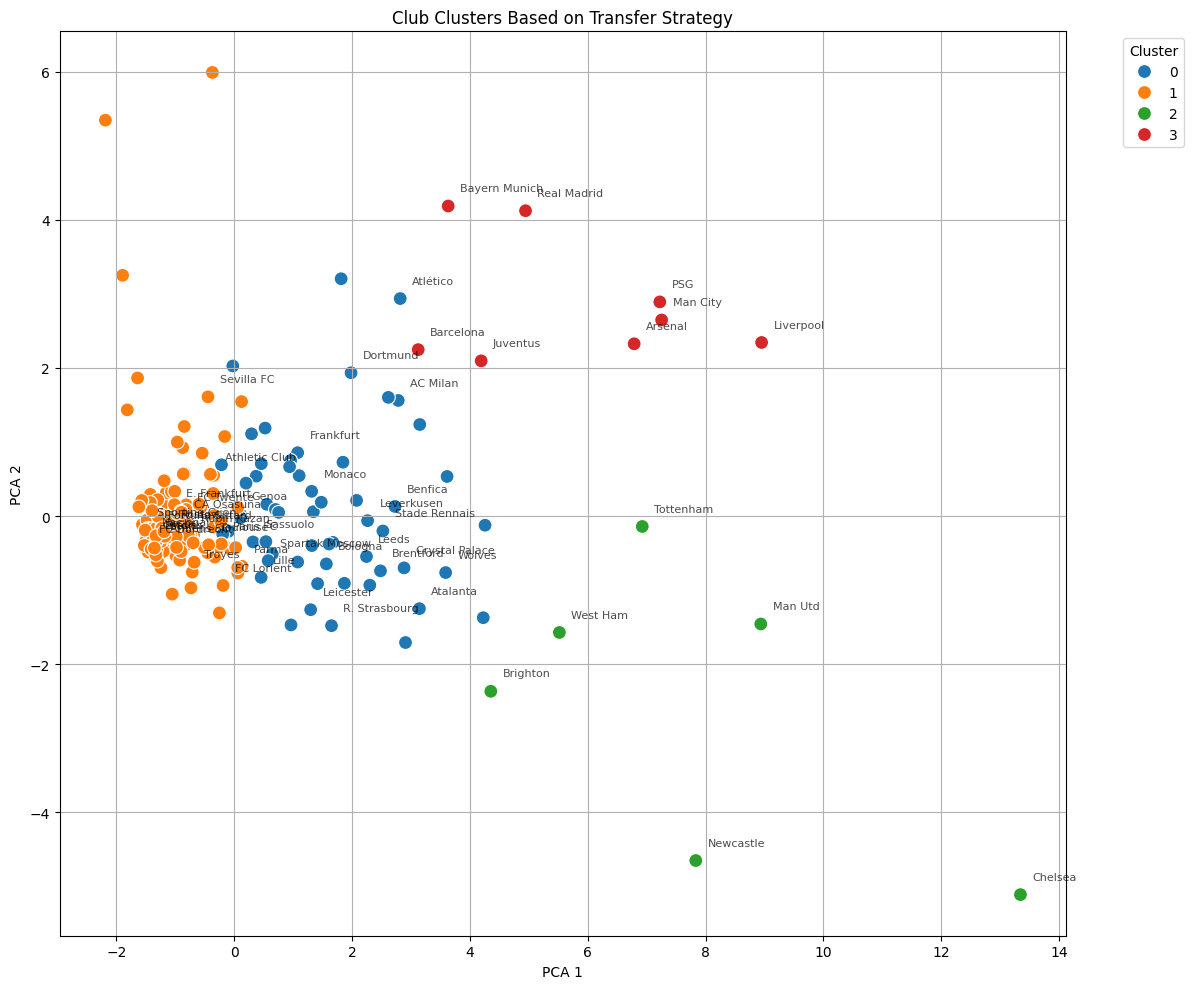

In [45]:
# PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

# Add PCA coordinates and clusters to the table
features['pca_1'] = pca_result[:, 0]
features['pca_2'] = pca_result[:, 1]

# If club names exist in club_stats_new, attach them
features['club'] = club_stats_new['club'].values

# Select up to 20 random clubs from each cluster for labeling
labeled_samples = features.groupby('cluster').apply(
    lambda x: x.sample(min(20, len(x)), random_state=42)
).reset_index(drop=True)

# Visualization
plt.figure(figsize=(12, 10))
sns.scatterplot(data=features, x='pca_1', y='pca_2', hue='cluster', palette='tab10', s=100)

# Labels
for _, row in labeled_samples.iterrows():
    plt.text(
        row['pca_1'] + 0.2,
        row['pca_2'] + 0.2,
        row['club'],
        fontsize=8,
        alpha=0.7
    )

plt.title('Club Clusters Based on Transfer Strategy')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

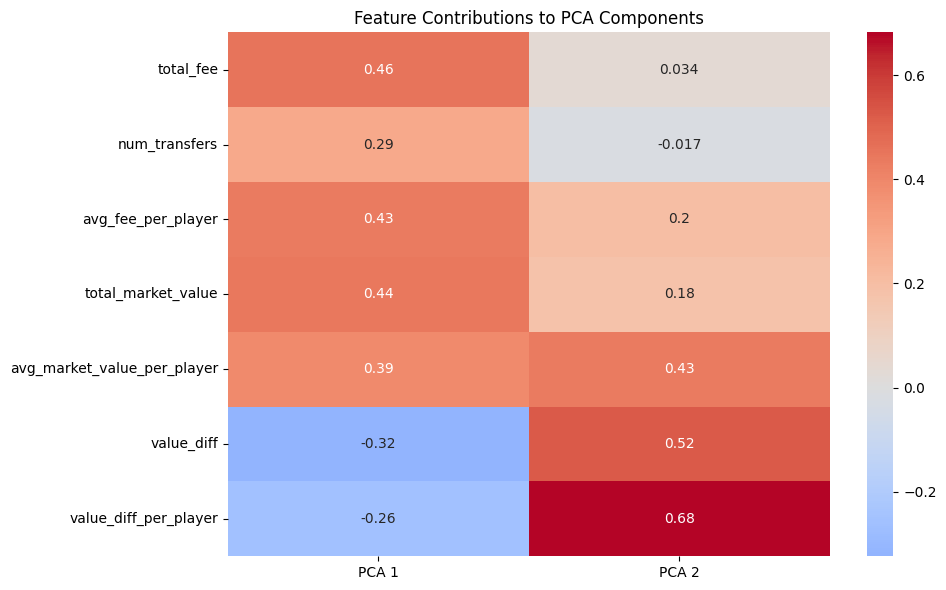

In [46]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

pca_features = [
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]

pca_components = pd.DataFrame(
    pca.components_,
    columns=pca_features,
    index=['PCA 1', 'PCA 2']
)

plt.figure(figsize=(10, 6))
sns.heatmap(pca_components.T, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Contributions to PCA Components')
plt.tight_layout()
plt.show()

In [48]:
# Group by cluster and print the list of clubs
for cluster_id, group in features.groupby('cluster'):
    print(f"\nCluster {cluster_id}:")
    print(group['club'].tolist())


Cluster 0:
['AC Milan', 'Ajax', 'Aston Villa', 'Atalanta', 'Atlético', 'Benfica', 'Bologna', 'Bournemouth', 'Brentford', 'Burnley', 'Cagliari', 'Como', 'Crystal Palace', 'Dortmund', 'Everton', 'Feyenoord', 'Fiorentina', 'Frankfurt', 'Fulham', 'Genoa', 'Hellas Verona', 'Hoffenheim', 'Inter', 'Ipswich', 'Lazio', 'Lecce', 'Leeds', 'Leicester', 'Leipzig', 'Lens', 'Leverkusen', 'Lille', 'Lyon', 'Marseille', 'Monaco', 'Napoli', 'Nice', "Nott'm Forest", 'PSV', 'Porto', 'R. Strasbourg', 'Real Betis', 'Roma', 'Sassuolo', 'Southampton', 'Spartak Moscow', 'Sporting', 'Stade Rennais', 'Stuttgart', 'Sunderland', 'Torino', 'Udinese', 'Union Berlin', 'Villarreal', 'Wolfsburg', 'Wolves', 'Zenit S-Pb']

Cluster 1:
['1.FC Köln', '1.FC Nuremberg', '1.FSV Mainz 05', 'AJ Auxerre', 'AZ Alkmaar', 'Akhmat Grozny', 'Akron Tolyatti', 'Alavés', 'Alverca', 'Amiens SC', 'Angers SCO', 'Arm. Bielefeld', 'Arouca', 'Arsenal Tula', 'Atalanta BC', 'Athletic Club', 'Atlético Madrid', 'Augsburg', 'B. Leverkusen', 'Baltik

## Cluster Characteristics

**Cluster 0:**  
Clubs with limited budgets that still manage to compete successfully with clubs from clusters 1 and 2 for trophies and qualification to prestigious European competitions.

On average, these clubs sign **a relatively large number of players** (around 20), but for **moderate transfer fees** (around €10M per player). Player values generally remain stable, meaning that the difference between market value and transfer spending is close to zero.

Some of these clubs dominate their domestic leagues (for example in **Italy, the Netherlands, and Russia**). However, this strategy is often **not sufficient to consistently compete at the very top level** in leagues such as **England, Spain, or Germany**.

---

**Cluster 1:**  
Low-budget clubs that sign a relatively small number of players (on average about 8) for relatively low transfer fees (around €1.9M per player). These clubs operate under strict financial constraints.

A positive aspect is the **positive difference between the players’ current market value and the money spent on their transfers** (on average about €380K per player).

The typical sporting objectives of these clubs include:
- promotion to the top division,
- avoiding relegation,
- qualifying for European competitions.

---

**Cluster 2:**  
Clubs that sign **a large number of players** (on average about 23) and spend **very high transfer fees** (around €37M per player). These are usually clubs with wealthy owners and large fan bases.

However, these clubs tend to **overpay significantly**, as many of the players they acquire either decrease in value or do not grow enough in market value. On average, they overpay **around €11M per player** based on the players’ current market value.

These clubs have also been relatively **unsuccessful in the past 3–4 years**, suggesting that excessive and poorly planned spending does not necessarily lead to good sporting results.

---

**Cluster 3:**  
Top clubs with a **balanced transfer strategy**. While they may occasionally overpay for players they truly need, the difference between the current market value and the transfer fee per player tends to be close to zero.

These clubs typically:
- regularly participate in European competitions,
- compete for domestic and international trophies,
- often win those competitions,
- have very large global fan bases.

In short, these are **elite football clubs** (and Tottenham).

## Feature Selection

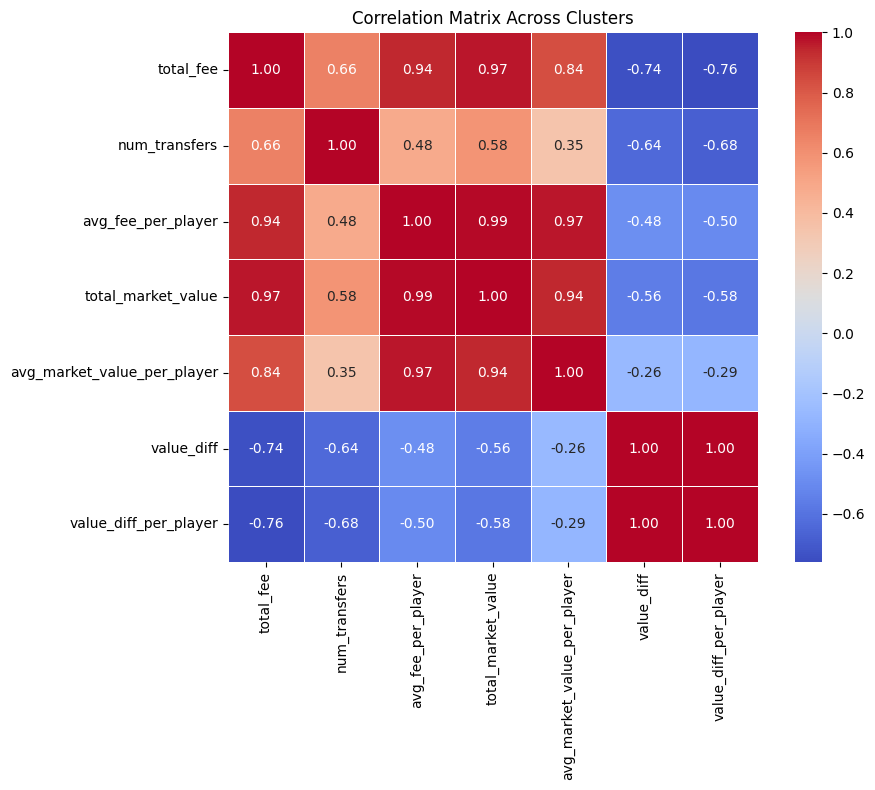

In [49]:
# Group by clusters and compute average feature values
cluster_summary = features.groupby('cluster')[[
    'total_fee',
    'num_transfers',
    'avg_fee_per_player',
    'total_market_value',
    'avg_market_value_per_player',
    'value_diff',
    'value_diff_per_player'
]].mean()

# Compute correlation matrix
corr = cluster_summary.corr()

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title('Correlation Matrix Across Clusters')
plt.tight_layout()
plt.show()

In [50]:
# Total absolute contribution of each feature across all PCA components
pca = PCA()
pca.fit(features_scaled)
explained_variance = pca.explained_variance_ratio_
components = pd.DataFrame(pca.components_, columns=cluster_summary.columns)
feature_importance = components.abs().sum(axis=0)

# Sort features by importance
top_features = feature_importance.sort_values(ascending=False).head(5)
print("Top features by importance:")
print(top_features)

# Keep only the top features
selected_features = features[top_features.index].copy()

Top features by importance:
avg_fee_per_player             2.452954
avg_market_value_per_player    2.399318
total_market_value             2.198623
value_diff                     2.191812
total_fee                      2.093232
dtype: float64


## Building Other Models (Including Ensemble Models)

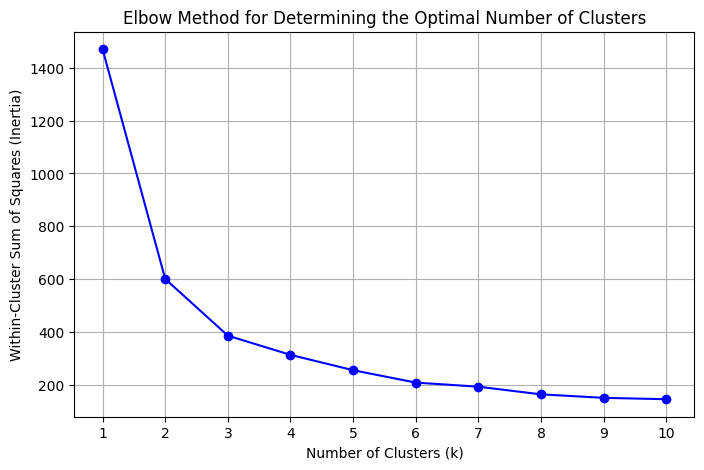

In [51]:
# Apply the Elbow Method using the selected features

# Feature scaling
selected_features = [
    'avg_market_value_per_player',
    'avg_fee_per_paid_player',
    'total_market_value',
    'value_diff_per_player',
    'value_diff'
]

X = club_stats[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Method for Determining the Optimal Number of Clusters')
plt.xticks(k_range)
plt.grid(True)
plt.show()

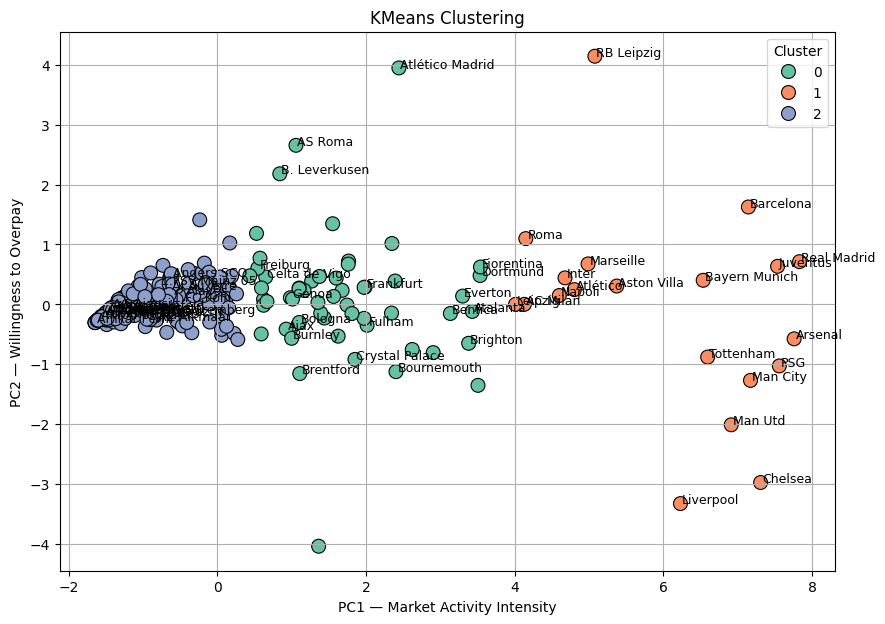

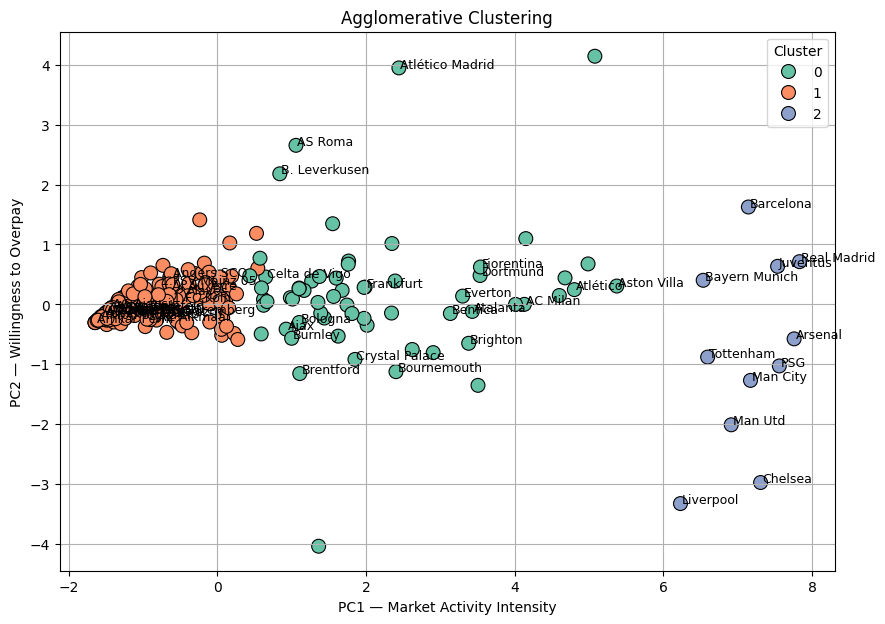

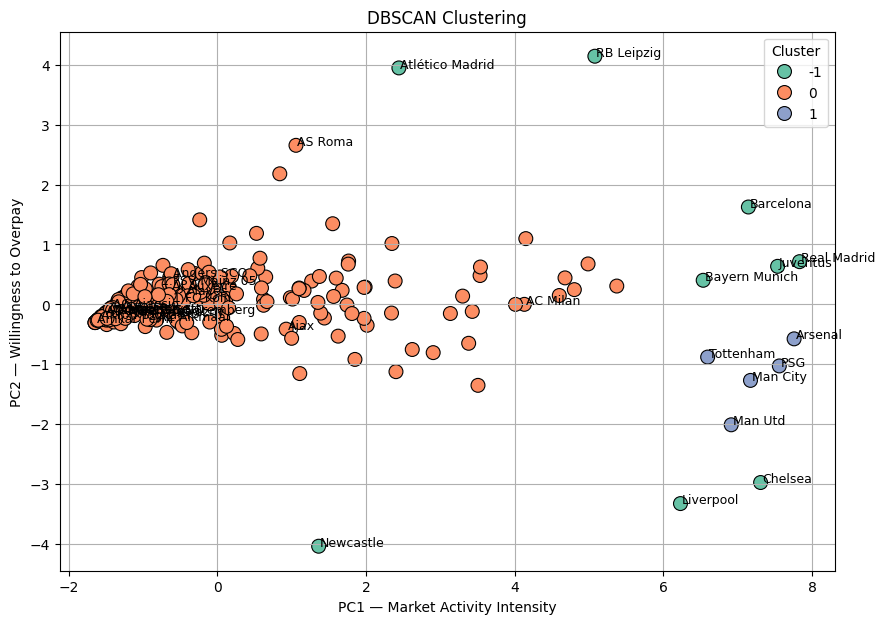

In [52]:
selected_features = [
    'avg_market_value_per_player',
    'avg_fee_per_paid_player',
    'total_market_value',
    'value_diff_per_player',
    'value_diff'
]

X = club_stats[selected_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
club_stats['PC1'] = X_pca[:, 0]
club_stats['PC2'] = X_pca[:, 1]

kmeans = KMeans(n_clusters=3, random_state=42)
club_stats['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
club_stats['cluster_agglo'] = agglo.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.5, min_samples=3)
club_stats['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

def plot_clusters_with_labels(data, cluster_col, title):
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=data, x='PC1', y='PC2', hue=cluster_col, palette='Set2', s=100, edgecolor='black')
    plt.xlabel('PC1 — Market Activity Intensity')
    plt.ylabel('PC2 — Willingness to Overpay')
    plt.title(title)

    for cluster in data[cluster_col].unique():
        sub = data[data[cluster_col] == cluster].head(20)
        for _, row in sub.iterrows():
            plt.text(row['PC1'] + 0.02, row['PC2'], row['club'], fontsize=9)

    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

# Plot the clustering results
plot_clusters_with_labels(club_stats, 'cluster_kmeans', 'KMeans Clustering')
plot_clusters_with_labels(club_stats, 'cluster_agglo', 'Agglomerative Clustering')
plot_clusters_with_labels(club_stats, 'cluster_dbscan', 'DBSCAN Clustering')

**KMeans**:  
This algorithm divides all clubs into a predefined number of groups (clusters) by finding the centers of these groups and assigning each club to the nearest center. The process is repeated until the best possible separation is achieved.

**Agglomerative Clustering (Hierarchical Clustering)**:  
This method starts with each club as a separate group and then gradually merges them into larger clusters until the desired number of clusters is reached.

**DBSCAN**:  
This algorithm identifies **natural groupings of clubs** and ignores those that differ significantly from the rest (for example, extremely wealthy top clubs).

In [53]:
# Display feature weights in each principal component
pca_components = pd.DataFrame(
    pca.components_,
    columns=selected_features,
    index=['PC1', 'PC2']
)

print(pca_components.T.sort_values(by='PC1', ascending=False))

                                  PC1       PC2
avg_market_value_per_player  0.472733  0.030596
total_market_value           0.462444 -0.368806
avg_fee_per_paid_player      0.444833 -0.488032
value_diff                   0.437466  0.107571
value_diff_per_player        0.416432  0.783135


## Hyperparameter Tuning for the Best Model

In [54]:
score_kmeans = silhouette_score(X_scaled, club_stats['cluster_kmeans'])
score_agglo = silhouette_score(X_scaled, club_stats['cluster_agglo'])

print(f'Silhouette (KMeans): {score_kmeans:.3f}')
print(f'Silhouette (Agglomerative): {score_agglo:.3f}')
print(f'Silhouette (DBSCAN): {score_agglo:.3f}')

Silhouette (KMeans): 0.613
Silhouette (Agglomerative): 0.631
Silhouette (DBSCAN): 0.631


k = 2, silhouette score = 0.7045
k = 3, silhouette score = 0.6127
k = 4, silhouette score = 0.5348
k = 5, silhouette score = 0.5397
k = 6, silhouette score = 0.4754
k = 7, silhouette score = 0.4806
k = 8, silhouette score = 0.4737
k = 9, silhouette score = 0.4691
k = 10, silhouette score = 0.4740


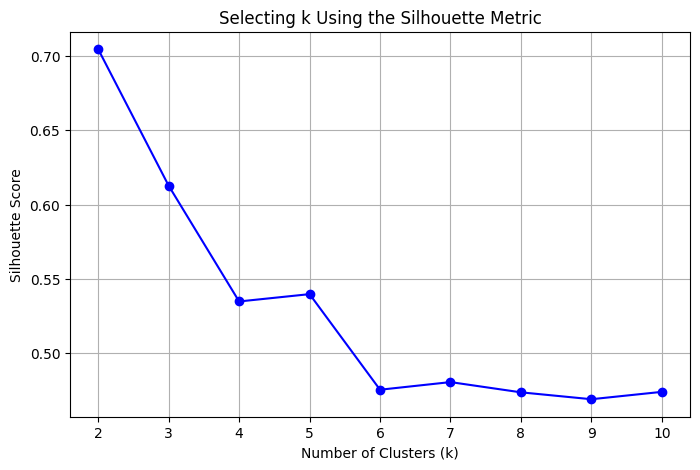


Best k value: 2 (maximum silhouette score = 0.7045)


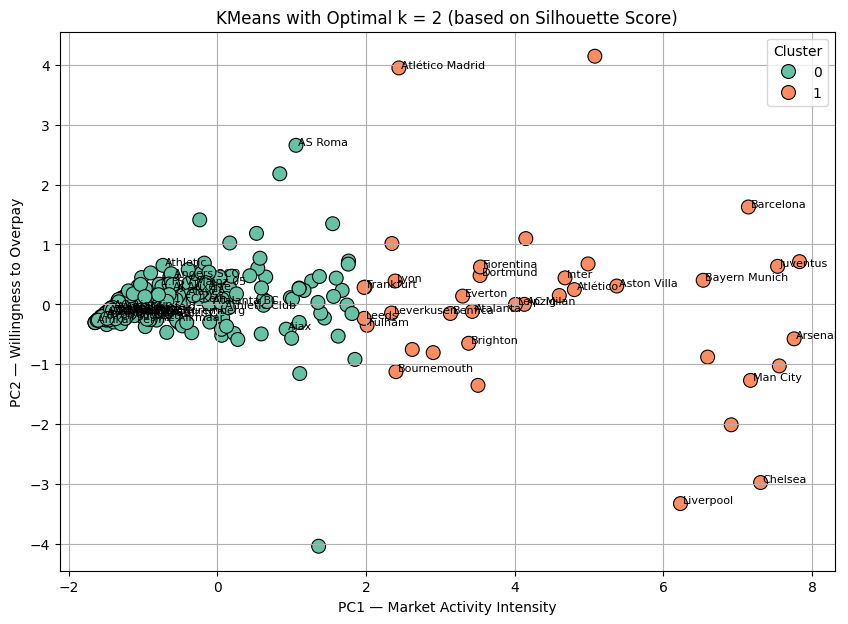

In [55]:
# Silhouette Score measures how close each observation is to its own cluster
# compared to other clusters.

# Test different values of k
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k}, silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Selecting k Using the Silhouette Metric")
plt.grid(True)
plt.show()

# Choose the best k
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k value: {best_k} (maximum silhouette score = {max(silhouette_scores):.4f})")

# Final model
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42)
club_stats['best_kmeans_cluster'] = final_kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=club_stats, x='PC1', y='PC2', hue='best_kmeans_cluster', palette='Set2', s=100, edgecolor='black')
plt.xlabel('PC1 — Market Activity Intensity')
plt.ylabel('PC2 — Willingness to Overpay')
plt.title(f"KMeans with Optimal k = {best_k} (based on Silhouette Score)")
plt.grid(True)

for cluster in club_stats['best_kmeans_cluster'].unique():
    subset = club_stats[club_stats['best_kmeans_cluster'] == cluster].head(25)
    for _, row in subset.iterrows():
        plt.text(row['PC1'] + 0.03, row['PC2'], row['club'], fontsize=8)

plt.legend(title="Cluster")
plt.show()

```markdown
**Cluster 1: Grand Investors**

**Typical representatives:**  
Chelsea, Manchester City, Manchester United, Arsenal, Bayern Munich, Barcelona, Juventus, Atlético Madrid, PSG, Inter, Roma

**Characteristics:**

Clubs with very high purchasing power.  
They make expensive transfers, often paying above the market value.

They can afford to overpay in order to strengthen the squad.  
Their strategy is focused on **immediate sporting success and brand growth**.

These are top-tier clubs that operate on the transfer market with virtually no financial constraints: they sign star players, pay premium prices, and often behave aggressively in the market.
```


**Cluster 0: Economical Clubs**

**Typical representatives:**  
Ajax, PSV, Mainz, Bologna, Brentford, Crystal Palace, Brighton, Sporting, Anderlecht, Toulouse

**Characteristics:**

These clubs operate under **budget constraints**.  
They tend to make **more balanced and efficient transfers**.

Their strategy often focuses on **developing young players and selling them later for profit**.  
They typically demonstrate **high deal efficiency**, often signing players below their market value.

These are clubs whose transfer strategy relies heavily on **scouting, analytics, and sustainable development**.

In [56]:
# Save the manually tuned KMeans model
joblib.dump(final_kmeans, 'best_kmeans_model.pkl')

['best_kmeans_model.pkl']

## Conclusion

## Project Conclusion

In this project, we analyzed the transfer strategies of football clubs from the top European leagues and the Russian Premier League starting from 2022, the post-COVID period when clubs returned to more stable financial and sporting conditions.

Using transfer data and market value indicators, we constructed a set of features that describe how clubs behave in the transfer market. These features included total transfer spending, number of signed players, average transfer fee, total and average market value, and the difference between market value and transfer spending.

Clustering analysis revealed several distinct **transfer strategies used by football clubs**:

- **Grand Investors** — wealthy clubs that spend heavily in the transfer market and often pay above market value in order to strengthen their squads quickly and maintain competitive dominance.
- **Economical Clubs** — clubs operating under tighter financial constraints that rely on scouting, analytics, and player development to buy undervalued players and potentially sell them for profit.
- **Balanced Top Clubs** — clubs that combine financial strength with relatively efficient transfer decisions, maintaining a balance between spending and player market value.
- **Competitive Mid-Budget Clubs** — clubs with moderate budgets that sign many players at reasonable prices and attempt to compete with richer clubs through efficient squad building.

Overall, the analysis demonstrates that **financial resources strongly influence transfer strategies**, but efficient recruitment and sustainable squad management can allow clubs with smaller budgets to remain competitive.

The results also highlight how different strategic approaches in the transfer market shape the structure of modern European football.

## Model Evaluation

Several clustering algorithms were tested to identify groups of clubs with similar transfer strategies:

- **KMeans**
- **Agglomerative Clustering**
- **DBSCAN**

To determine the optimal number of clusters for KMeans, the **Elbow Method** and **Silhouette Score** were used. The Silhouette analysis indicated the most appropriate number of clusters, after which the final KMeans model was trained using scaled features.

### Model Comparison

**KMeans**

KMeans produced the most interpretable and stable clusters. The algorithm clearly separated clubs according to their spending patterns, transfer volumes, and market value efficiency. The resulting clusters aligned well with real-world football structures (elite clubs, sustainable clubs, mid-budget competitors).

**Agglomerative Clustering**

Hierarchical clustering produced similar groupings but with slightly less stability and interpretability. While it captured hierarchical relationships between clubs, the cluster boundaries were less distinct compared to KMeans.

**DBSCAN**

DBSCAN was less effective for this dataset because the data does not naturally form density-based clusters. The algorithm also classified some clubs as noise due to large financial differences between clubs.

### Final Model

Based on interpretability, stability, and clustering quality, **KMeans was selected as the final model**.

The model successfully identifies meaningful strategic groups of football clubs and can be used as a tool to analyze transfer market behavior across leagues.

The trained model was saved for future use and potential extension of the analysis.